Portfolio #1: Exploratory Data Analysis

Dataset Overview: 
Source
This dataset was obtained from Kaggle and contains health and fitness tracking data. 

Description: 
THe dataset includes demographic, physiologial, and workout realted varaibles such as age, gender, height, weight, activity type, duration, calories burned, heart rate, sleep, stress level, daily steps, hydration, BMI, blood pressure, smoking status, and fitness level.

Size: 
After loading the dataset, I found that it contains 687,701 rows and 22 columns. 

Resreach QUestion: 
What fitness and physiological factors are most strongly associated with caloreis burned, and how do workout groups differ in their calorie expenditure?


In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
#Where the CSV file is loaded into a panda Dataframe
df = pd.read_csv("health_fitness_dataset.csv")
df.head()

,participant_id,date,age,gender,height_cm,weight_kg,activity_type,duration_minutes,intensity,calories_burned,...,stress_level,daily_steps,hydration_level,bmi,resting_heart_rate,blood_pressure_systolic,blood_pressure_diastolic,health_condition,smoking_status,fitness_level
0,1,2024-01-01,56,F,165.3,53.7,Dancing,41,Low,3.3,...,3,7128,1.5,19.6,69.5,110.7,72.9,NaN,Never,0.04
1,1,2024-01-04,56,F,165.3,53.9,Swimming,28,Low,2.9,...,7,7925,1.8,19.6,69.5,110.7,72.9,NaN,Never,0.07
2,1,2024-01-05,56,F,165.3,54.2,Swimming,21,Medium,2.6,...,7,7557,2.7,19.6,69.5,110.7,72.9,NaN,Never,0.09
3,1,2024-01-07,56,F,165.3,54.4,Weight Training,99,Medium,10.7,...,8,11120,2.6,19.6,69.5,110.7,72.9,NaN,Never,0.21
4,1,2024-01-09,56,F,165.3,54.7,Swimming,100,Medium,12.7,...,1,5406,1.5,19.6,69.5,110.7,72.9,NaN,Never,0.33


In [5]:
#Where Ill check the number of rows and columsn in the dataset
df.shape

(687701, 22)

#Observations:
The dataset contains 687,701 rows and 22 columns. 

In [6]:
df.dtypes

participant_id                int64
date                         object
age                           int64
gender                       object
height_cm                   float64
weight_kg                   float64
activity_type                object
duration_minutes              int64
intensity                    object
calories_burned             float64
avg_heart_rate                int64
hours_sleep                 float64
stress_level                  int64
daily_steps                   int64
hydration_level             float64
bmi                         float64
resting_heart_rate          float64
blood_pressure_systolic     float64
blood_pressure_diastolic    float64
health_condition             object
smoking_status               object
fitness_level               float64
dtype: object

###Observation:
The data set contains both quantitative and categorial variables. 

In [7]:
df.describe()

,participant_id,age,height_cm,weight_kg,duration_minutes,calories_burned,avg_heart_rate,hours_sleep,stress_level,daily_steps,hydration_level,bmi,resting_heart_rate,blood_pressure_systolic,blood_pressure_diastolic,fitness_level
count,687701.000000,687701.000000,687701.000000,687701.000000,687701.000000,687701.000000,687701.000000,687701.000000,687701.000000,687701.000000,687701.000000,687701.000000,687701.000000,687701.000000,687701.000000,687701.000000
mean,1499.781828,41.658602,168.587699,94.921981,70.011671,15.381302,131.454165,7.048799,5.252389,8628.370918,2.499427,22.733134,70.010547,120.001260,80.188079,9.524900
std,865.997215,13.581770,9.140811,22.461801,29.147251,9.985552,17.814744,0.972068,2.770029,2054.756608,0.579050,3.568383,5.074563,10.008917,8.239418,5.502485
min,1.000000,18.000000,145.000000,45.300000,20.000000,0.800000,82.000000,4.000000,1.000000,-419.000000,1.500000,14.200000,51.100000,78.000000,53.700000,0.020000
25%,749.000000,30.000000,161.700000,78.200000,45.000000,7.800000,118.000000,6.400000,3.000000,7203.000000,2.000000,20.100000,66.500000,113.100000,74.600000,4.770000
50%,1499.000000,42.000000,168.200000,94.600000,70.000000,13.000000,130.000000,7.000000,5.000000,8607.000000,2.500000,22.400000,70.000000,120.200000,80.100000,9.510000
75%,2249.000000,53.000000,175.300000,110.500000,95.000000,20.700000,144.000000,7.700000,8.000000,10027.000000,3.000000,25.100000,73.500000,127.000000,85.700000,14.230000
max,3000.000000,64.000000,198.500000,188.400000,120.000000,92.000000,206.000000,10.000000,10.000000,17241.000000,3.500000,38.800000,87.100000,152.700000,112.100000,21.930000


Observation: 
The summary statistics give me a better idea of the overall distribution of the numerical variables. I can see information such as the mean, minimum, maximum, and standard deviation for variables like duration_minutes and calories_burned. These statistics help me understand how much variation there is in workouts and health measurements across participants.

In [8]:
df["activity_type"].value_counts()

activity_type
Yoga               69961
Weight Training    69661
HIIT               69376
Dancing            69193
Cycling            69187
Basketball         68536
Tennis             68533
Walking            68077
Swimming           68032
Running            67145
Name: count, dtype: int64

OBservation: When I looked at the activity_type column, I saw that the dataset includes many different workout types such as yoga, weight training, HIIT, dancing, cycling, basketball, tennis, walking, swimming, and running. The counts appear fairly balanced across these activities, which should make it easier to compare how different workout types affect variables like calories burned.

In [9]:
df.isnull().sum()

participant_id                   0
date                             0
age                              0
gender                           0
height_cm                        0
weight_kg                        0
activity_type                    0
duration_minutes                 0
intensity                        0
calories_burned                  0
avg_heart_rate                   0
hours_sleep                      0
stress_level                     0
daily_steps                      0
hydration_level                  0
bmi                              0
resting_heart_rate               0
blood_pressure_systolic          0
blood_pressure_diastolic         0
health_condition            490275
smoking_status                   0
fitness_level                    0
dtype: int64

Observation: Most of the columns in the dataset do not contain missing values, which suggests that the dataset is relatively clean. However, the health_condition column has a very large number of missing values. Because more than half of the entries in this column are missing, I decided it would be better to remove this column before continuing with the analysis.

In [10]:
#I'll drop health conditions because  it has a lot of data that is missing and it will not be useful for my analysis
df = df.drop(columns=["health_condition"])


Oobservation: I removed the health_condition column because it contained too many missing values to be useful for analysis. Keeping a column with this many missing entries could introduce bias or make the analysis harder to interpret, so removing it helps keep the dataset cleaner.

In [11]:
df.columns

Index(['participant_id', 'date', 'age', 'gender', 'height_cm', 'weight_kg',
       'activity_type', 'duration_minutes', 'intensity', 'calories_burned',
       'avg_heart_rate', 'hours_sleep', 'stress_level', 'daily_steps',
       'hydration_level', 'bmi', 'resting_heart_rate',
       'blood_pressure_systolic', 'blood_pressure_diastolic', 'smoking_status',
       'fitness_level'],
      dtype='object')

Observations: 
I removed the health_condition column because it contained too many missing values to be useful for analysis. Since over half of the entries in this column were missing, keeping it could introduce bias or reduce the reliability of the results.

After removing this column, the dataset now contains 687,701 rows and 21 columns. This helps ensure that the analysis is based on more complete and meaningful data.

Section 2: Correlations & Group Comparisons

In [12]:
#Dye to the dataset having over 680,000 rowos I cwill create a smaller random sample of 10,000 rows to make it easier to work with.
corr_matrix = df.drop(columns=["participant_id"]).corr(numeric_only=True)

corr_matrix

,age,height_cm,weight_kg,duration_minutes,calories_burned,avg_heart_rate,hours_sleep,stress_level,daily_steps,hydration_level,bmi,resting_heart_rate,blood_pressure_systolic,blood_pressure_diastolic,fitness_level
age,1.000000,0.008300,0.032015,0.000903,0.011291,-0.564767,-0.000548,0.000644,-0.000694,0.000978,0.061308,-0.003733,-0.015980,-0.008390,0.002722
height_cm,0.008300,1.000000,0.472808,-0.000917,0.172910,-0.004638,-0.000325,-0.004562,-0.000589,-0.000258,0.343453,0.002921,-0.015442,-0.002393,0.001467
weight_kg,0.032015,0.472808,1.000000,-0.001602,0.365218,-0.017419,-0.001885,-0.002565,-0.343977,-0.000591,0.573853,-0.000297,0.009458,-0.004938,0.761940
duration_minutes,0.000903,-0.000917,-0.001602,1.000000,0.641077,-0.000859,0.002480,0.000485,-0.000005,-0.000291,-0.001404,0.003342,0.001092,0.000330,0.005267
calories_burned,0.011291,0.172910,0.365218,0.641077,1.000000,0.121138,-0.000019,-0.001756,-0.126245,-0.001024,0.210347,-0.000314,0.003279,-0.000322,0.281815
avg_heart_rate,-0.564767,-0.004638,-0.017419,-0.000859,0.121138,1.000000,-0.000343,0.000219,-0.000484,0.000175,-0.034370,0.001777,0.008187,0.004926,0.000372
hours_sleep,-0.000548,-0.000325,-0.001885,0.002480,-0.000019,-0.000343,1.000000,0.001374,0.001025,0.000609,-0.000651,-0.001156,0.000949,-0.000672,-0.001894
stress_level,0.000644,-0.004562,-0.002565,0.000485,-0.001756,0.000219,0.001374,1.000000,0.000804,0.001050,-0.003107,-0.001499,0.000082,-0.000566,0.000431
daily_steps,-0.000694,-0.000589,-0.343977,-0.000005,-0.126245,-0.000484,0.001025,0.000804,1.000000,0.000374,0.000287,-0.000805,0.000437,0.000766,-0.449572
hydration_level,0.000978,-0.000258,-0.000591,-0.000291,-0.001024,0.000175,0.000609,0.001050,0.000374,1.000000,0.000428,0.002902,0.001809,0.000157,-0.000996


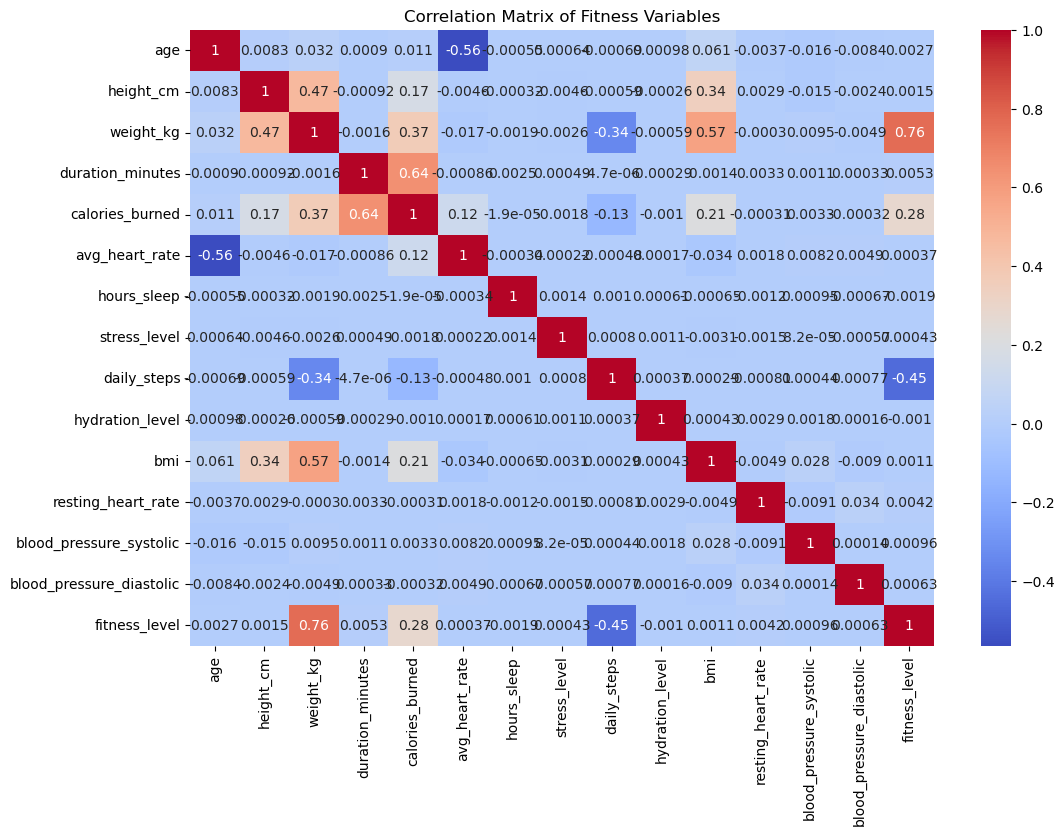

In [ ]:
# Computing correlations between all numerical variables
plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix of Fitness Variables")
plt.show()

Observations: 

From looking at the heatmap, I can see how the different numerical variables in the dataset relate to each other. The main relationship I noticed is between duration_minutes and calories_burned. This makes sense because the longer someone works out, the more calories they are going to burn. I also see a strong relationship between weight_kg and bmi, which makes sense since BMI depends on weight. There is also a very distinct negative relationship between age and avg_heart_rate, which suggests that heart rate tends to go down a bit as people get older.
Overall, the heatmap helps me understand which variables are actually connected and which ones are not, and it gives me a better idea of what to focus on next.

In [14]:
df.groupby("activity_type")["calories_burned"].mean().sort_values(ascending=False)

activity_type
HIIT               25.994067
Running            21.327712
Cycling            18.498666
Basketball         17.357854
Tennis             15.846564
Swimming           15.188164
Weight Training    13.040469
Dancing            11.990842
Walking             8.229493
Yoga                6.506351
Name: calories_burned, dtype: float64

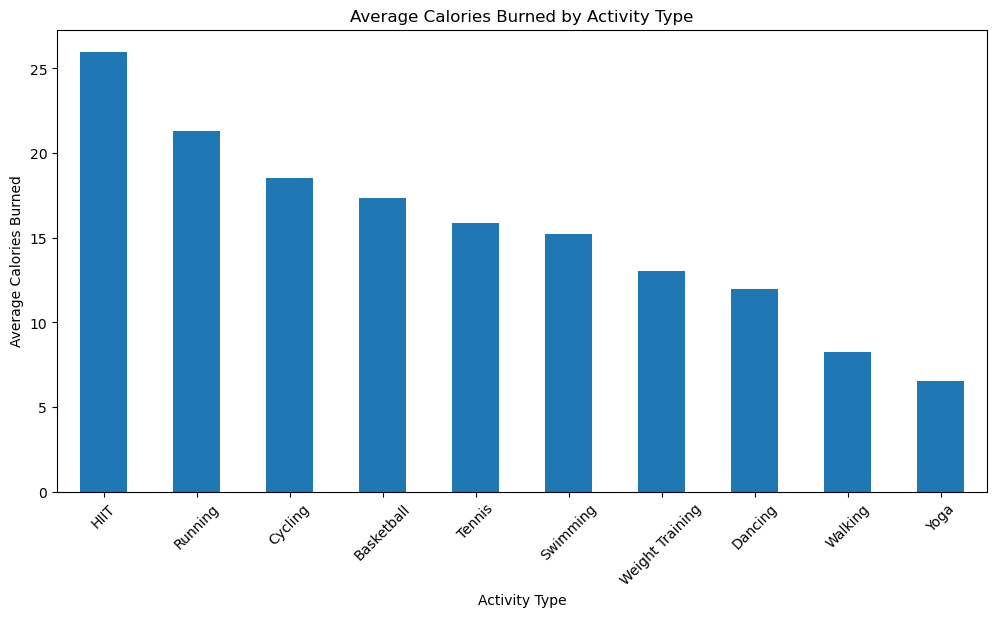

In [17]:
plt.figure(figsize=(12,6))

df.groupby("activity_type")["calories_burned"].mean().sort_values(ascending=False).plot(kind="bar")

plt.title("Average Calories Burned by Activity Type")
plt.xlabel("Activity Type")
plt.ylabel("Average Calories Burned")
plt.xticks(rotation=45)

plt.show()

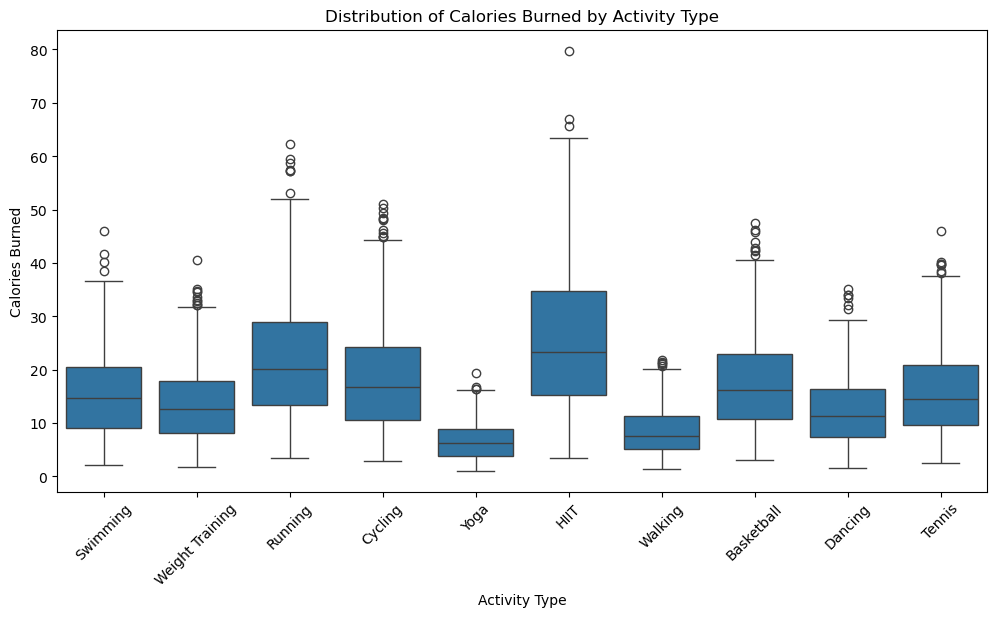

In [19]:
# sample data to make plotting faster
df_sample = df.sample(10000, random_state=42)

plt.figure(figsize=(12,6))

sns.boxplot(data=df_sample, x="activity_type", y="calories_burned")

plt.title("Distribution of Calories Burned by Activity Type")
plt.xlabel("Activity Type")
plt.ylabel("Calories Burned")

plt.xticks(rotation=45)

plt.show()

Group Comparison ANalysis:

To compare different workout types, I looked at the average calories burned for each activity. From the results, I noticed that HIIT burns the most calories on average, followed by running and cycling. This makes sense to me because these are more intense workouts and require more energy. On the other hand, activities like yoga and walking burn the least calories on average. These are lower intensity workouts, so it makes sense that they don’t burn as many calories. The bar chart helps me clearly compare the average calories across activities, while the boxplot shows how spread out the values are for each workout type. Overall, this shows that the type of workout really affects how many calories are burned, and higher intensity workouts tend to burn more calories.

### SECTION 3: Advanced Visualizations:

#1 Pairplot

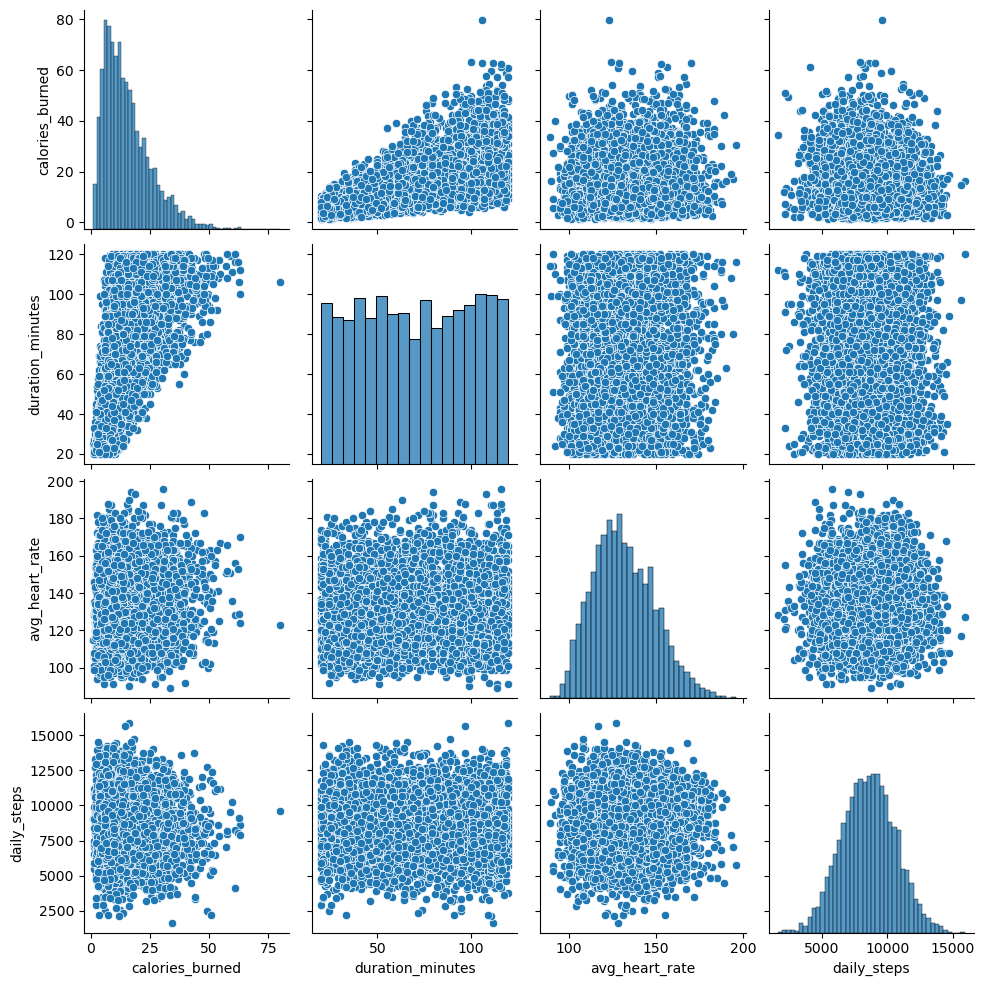

In [21]:
# Sample for speed (dataset is huge)
df_sample = df.sample(5000, random_state=42)

sns.pairplot(df_sample[[
    "calories_burned",
    "duration_minutes",
    "avg_heart_rate",
    "daily_steps"
]])

plt.show()

###Pair Plot Analysis:

I used a pair plot to look at the relationships between multiple numerical variables at the same time. From the visualziations, I noticed that calories burned and duration_minutes have a clear postive realationshi, which makes sense because longer workouts burn more calories. 

Some of the other variables, like avg_heart_rate and daily_steps, do not show very strong relationships with calories burned, but the plot still helps me see how eveyrhting interacts.

Overall, this visualization helps me better understand patterns between multiple variables that are harder to see just from a correlation table. 

#2 Violin Plot 

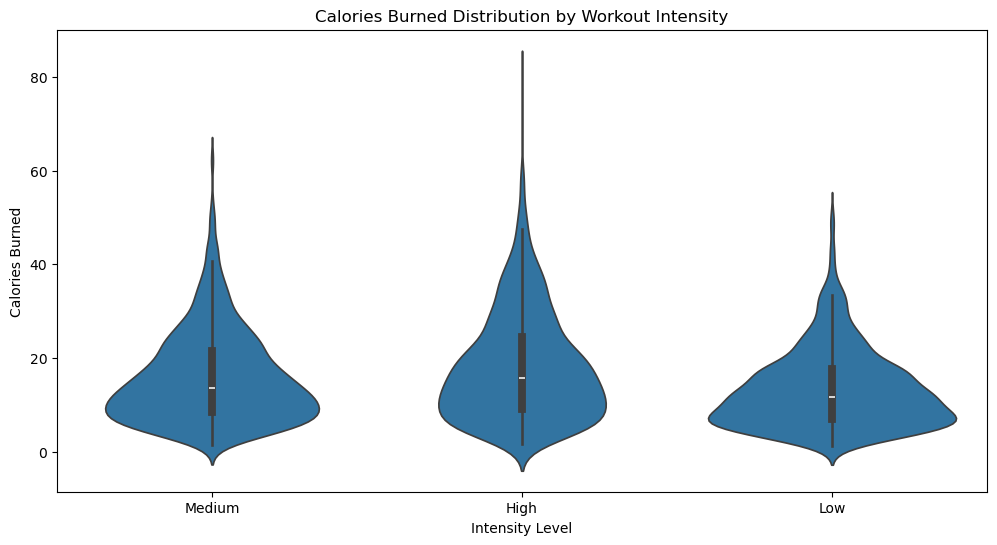

In [22]:
plt.figure(figsize=(12,6))

sns.violinplot(data=df_sample, x="intensity", y="calories_burned")

plt.title("Calories Burned Distribution by Workout Intensity")
plt.xlabel("Intensity Level")
plt.ylabel("Calories Burned")

plt.show()

#Violin Plot Analysis:

I used a violin plot to compare how calories burned changes across different workout intensity levels. From this graph, I noticed that high intesnsity wrokuts tend to burn more caloried and also jhave a wider spread of values. This means there is more variation, but overall higher calorei brun. Medium intensity workouts fall in the middle, while low intensity workouts are more concentrated at lower calorie values. 

This makes sense to me beacause higher intensity workouts require more effforts and energy, which leads to more calories burned.

Overall, this shows that workout intensity plays a big role in calorie expenditure. 


#3 Regression Plot

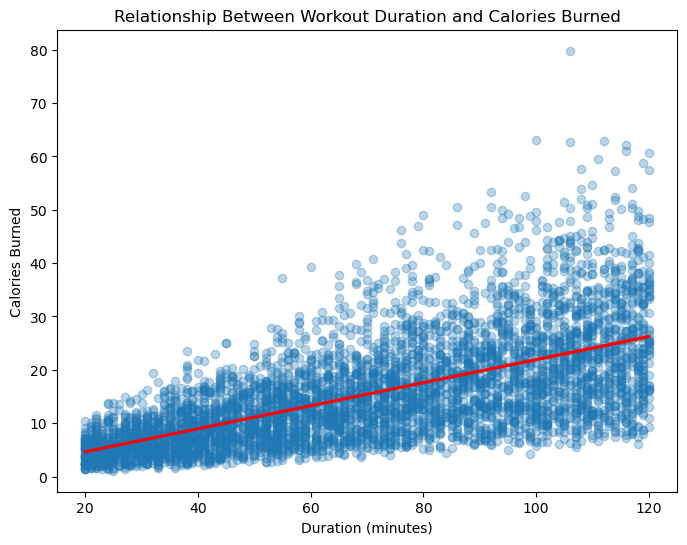

In [27]:
plt.figure(figsize=(8,6))

sns.regplot(
    data=df_sample,
    x="duration_minutes",
    y="calories_burned",
    scatter_kws={"alpha":0.3},
    line_kws={"color": "red"}
)

plt.title("Relationship Between Workout Duration and Calories Burned")
plt.xlabel("Duration (minutes)")
plt.ylabel("Calories Burned")

plt.show()

#Regresion Plot Analysis:

Here I used a regression plkot to better understnad the relationships betweem work duarion and calories burned. From the graph, I noticed a clear upward trend, meaing that as workout duration increases, calories burned also increases. The red line makes it easier to see this trend, and it shows that there is a positive relationship between the 2 variables. I also noticed that while the overall trend is increasing, the points are somewhat spread out. Meaning that even though longer workouts usually burn more calories, there is still some variation depending on other factors like intensity or activity type. All in all, this confirms what I had seen earlier in the correlation and piar plot, that duration is one fo the main factors affecting calories burned. 


## Section 4: Hypothesis Testing

### Test 1: Correlation Between Duration and Calories Burned

I want to test whether there is a real relationship between workout duration and calories burned.

H₀ (null hypothesis): There is no relationship between duration_minutes and calories_burned.

H₁ (alternative hypothesis): There is a relationship between duration_minutes and calories_burned.

I am using a Pearson correlation test because both variables are numerical and I want to test if the relationship is statistically significant.

I will use a significance level of α = 0.05.

In [28]:
from scipy import stats

r, p_value = stats.pearsonr(df_sample["duration_minutes"], df_sample["calories_burned"])

print("Pearson r:", r)
print("p-value:", p_value)

Pearson r: 0.6366728367500096
p-value: 0.0


### Interpretation (Test 1)

The p-value is extremely small, which is less than 0.05, so I reject the null hypothesis. Meanign there is a statistically significant relationship between workout duration and calories burned. The Pearson correlation value is about 0.64, which indicates a moderately strong positive relationship. This means that as workout duration increases, calories burned also tends to increase. This matches what I observed earlier in the visualizations, especially in the regression plot where there was a clear upward trend. One thing to keep in mind is that due to the dataset being very large, even smaller relationships can appear statistically significant.

### Test 2: Calories Burned for High vs Low Intensity Workouts

Now I want to test whether high intensity workouts burn more calories than low intensity workouts.

H₀ (null hypothesis): The average calories burned is the same for high and low intensity workouts.

H₁ (alternative hypothesis): The average calories burned is different between high and low intensity workouts.

I am using a two-sample t-test because I am comparing the means of two groups.

I will use a significance level of α = 0.05.

In [30]:
# This test compares the average calories burned between high intensity and low intensity workouts

high = df[df["intensity"] == "High"]["calories_burned"]
low = df[df["intensity"] == "Low"]["calories_burned"]

t_stat, p_value = stats.ttest_ind(high, low)

print("t-statistic:", t_stat)
print("p-value:", p_value)

t-statistic: 154.09906908241493
p-value: 0.0


### Interpretation (Test 2)

The p-value is extremely small, which is less than 0.05, so I reject the null hypothesis.Meaning again that there is a statistically significant difference in calories burned between high and low intensity workouts. The t-statistic is very large (around 154), which shows that the difference between the two groups is very strong. This matches what I saw earlier in the violin plot, where high intensity workouts clearly burned more calories than low intensity workouts. One limitation is that this test does not consider other factors like workout duration or type of activity, which could also affect calories burned.